# Neural Networks for Data Science
## End-of-term homework: KV Cache handling and compression

**Name**: *Flavio Mangione*

**Matricola**: *2201201*

> ✍ Upload the completed notebook **at least three days** before your expected exam's date on the Google Classroom page. For example, for the **January 12th** session, you should upload it by **January 9th, 23:59 Rome time**.

In [1]:
!git clone https://github.com/Flavio-Mangione/GPT1-from-scratch-jax.git

import sys
sys.path.append('/content/GPT1-from-scratch-jax')

Cloning into 'GPT1-from-scratch-jax'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 57 (delta 23), reused 47 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 3.46 MiB | 9.06 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [2]:
%pip -q install datasets optax equinox matplotlib contractions

# Pre-processing and cleaning
import re
import html
import contractions

# jax
import jax
import jax.numpy as jnp
import jax.random as jrand
import equinox as eqx
import optax

# Dataset
from datasets import load_dataset

# Import my model
from Model import GPT1

# Metrics used for training and evaluation
from utils.metrics import cross_entropy_loss, val_step, compute_val_loss, top_k_accuracy

# Visualization
import matplotlib.pyplot as plt
from utils.visualizzation import plot_attention_bar

# Other
import time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.0 MB/s eta 0:00:00


### Instructions

1. The homework has two exercises, only the first one is mandatory to access the oral exam.
2. The second exercise is graded (4 points). Without it, the maximum mark for the oral will be 26.
3. Lode requires *exceptional* solutions and orals (top 5%).
4. If you score well on the project but poorly on the oral, the grade can be kept for the entire academic year (up to October 2026).

**IMPORTANT - read carefully before starting**:

> 🟨 *External material*: if you use external material (including AI tools), reference it *explicitly* in the corresponding cell. Copy-paste *is not allowed*.

> 🔵 *Grammar*: please try to be precise and provide nice-to-read descriptions.

> 🟥 *JAX*: the homework must be done _in JAX_ or high-level JAX libraries (Haiku, Flax, equinox, ...). You cannot use libraries that directly solve the core exercise(s). When in doubt, ask.

> 🟪 *Math*: you can use LaTeX in Markdown if you need to write equations or if you need generic math notation.


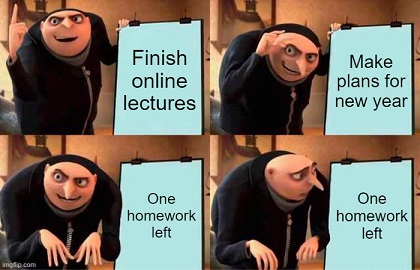

## Warmup: Data loading

For this part, select a dataset that you like, keeping in mind task complexity with respect to the available hardware.

*   You can use any data processing you want (PyTorch data loaders, TensorFlow datasets, Grain, HuggingFace Dataset, ...).
*   Any data type (tabular, images, videos, audio, time-series, graphs, ...) is okay.

A few repositories that you can look at:

1. The catalog of [TensorFlow Datasets](https://www.tensorflow.org/datasets/).
2. The [Kaggle catalog](https://www.kaggle.com/data). For downloading data from Kaggle on Google Colab, you will need to [load your Kaggle authentication token](https://colab.research.google.com/github/corrieann/kaggle/blob/master/kaggle_api_in_colab.ipynb).
3. The [UCI Machine Learning Repository](https://archive.ics.uci.edu/datasets).
4. The [🤗 HuggingFace Datasets](https://huggingface.co/docs/datasets/) repository.

You are not bound to these; any open repository is okay. The choice of dataset will not influence the mark.

✍ **DESCRIPTION OF THE CODE**

*Provide a description of the dataset below (e.g., source, task, bibliographic reference if necessary...), both as text and in the comments of the code. Describe the preprocessing you have applied.*

## Dataset Description
[Ag-News dataset](https://huggingface.co/datasets/sh0416/ag_news) from Hugging Face is built as a text classification dataset.

It consists of four types of news collections:
*   World;
*   Sports;
*   Business;
*   Sci/Tech.

The dataset is composed of 120,000 training samples and 7,600 test samples, each including two features (*title* and *description*) and one label indicating the corresponding category.

Although it is primarily designed for classification tasks, it can also be used for text generation purposes to produce short news articles or headlines conditioned on specific topics.

---

## Pre-processing and Project Task

Before tokenization, the text sequences are adapted and cleaned into a suitable format for model training. In detail, HTML entities are fixed using the `html` library, contractions are expanded (I'll => I will) using the `contractions` library and news agency tags are removed (typically located at the beginning of each news description).

### Example:

**Before pre-processing**

I #39;ll be No.1 - Owen Michael Owen is confident that he will be a success at Real Madrid following his 8m move from Liverpool.

**After pre-processing**

i will be no 1 owen michael owen is confident that he will be a success at real madrid following his 8m move from liverpool

---

Finally, the model will be trained on the short descriptions of each news article provided in the dataset, using *Cross-Entropy loss* and *Perplexity*.

The goal of this task is to train a model capable of generating coherent and contextually relevant text for each of the four news categories based on corresponding prompts. The model should learn the underlying structure, style, and vocabulary specific to each category.


In [3]:
# Load AG News dataset from Hugging Face
dataset = load_dataset("ag_news")

train_ds = dataset["train"]
test_ds = dataset["test"]

print(f"Train size: {len(train_ds)}")
print(f"Test size : {len(test_ds)}")

# Split train/validation (set a seed for reproducibility)
val_size = int(0.1 * len(train_ds))
split = train_ds.train_test_split(test_size=val_size, seed=426)

train_ds = split["train"]
val_ds = split["test"]

print(f"Train split: {len(train_ds)}")
print(f"Val split  : {len(val_ds)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train size: 120000
Test size : 7600
Train split: 108000
Val split  : 12000


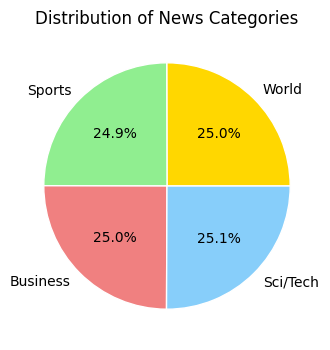

In [4]:
# Compute label frequencies and plot the class distribution of the AG News training set

labels = jnp.array(train_ds["label"])
labels = jnp.bincount(labels,length=4)
colors = ['gold','lightgreen','lightcoral','lightskyblue']

plt.figure(figsize=(8,4))
plt.pie(labels,labels=["World","Sports","Business","Sci/Tech"],autopct="%1.1f%%",colors = colors,wedgeprops={"linewidth":1,"edgecolor":"white"})
plt.title("Distribution of News Categories")
plt.show()

In [5]:
# Plot 5 random samples from the training set
for i in range(5):
    idx = jrand.randint(jrand.PRNGKey(i), 1, 0, len(train_ds))
    sample = train_ds[idx]
    print(f"Sample {i+1}:\n Text: {' '.join(html.unescape(sample['text']))}\n")

Sample 1:
 Text: Documents detail abuse of detainees WASHINGTON -- US Marines fired a pistol in a mock execution involving four young Iraqi looters and shocked another Iraqi detainee with an electric transformer until he ''danced, quot; a document made public yesterday showed.

Sample 2:
 Text: Arafat in good health, doctor says The private doctor said Wednesday Palestinian President Yasser Arafat is in good health and tests showed his stomach is normal. Ashraf Kurdi, a neurologist and former Jordanian 

Sample 3:
 Text: I #39;ll be No.1 - Owen Michael Owen is confident that he will be a success at Real Madrid following his 8m move from Liverpool. 

Sample 4:
 Text: At posh hotels, iPod a high-tech mint on the pillow Apple's digital music player becomes the latest amenity at swank hotels, and ups its status as a pop-culture icon.&lt;br /&gt; Photo: Preloaded iPod in your next hotel room?

Sample 5:
 Text: Eurostar turns 10, still sees red Eurostar will hold celebrations in three countr

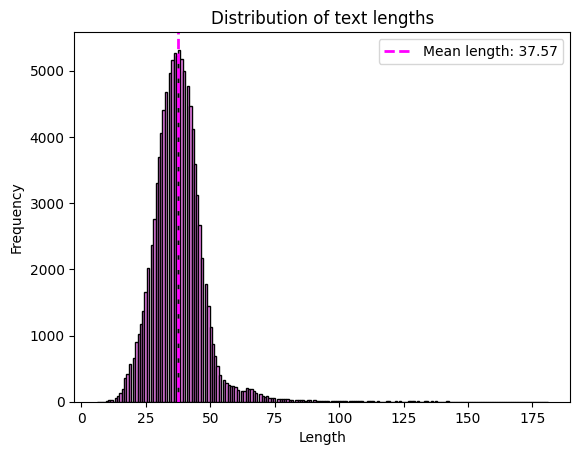

In [6]:
def tokenize(text):
    # Fix malformed HTML entities (e.g. #39;)
    text = re.sub(r'(?<!&)#(\d+);', r'&#\1;', text)
    text = re.sub(r'(?<!&)#([a-zA-Z]+);', r'&\#\1;', text)
    # Decode HTML entities
    text = html.unescape(text)
    text = text.lower()
    # Remove residual HTML tags (<b>, </b>, <br>)
    text = re.sub(r'<[^>]+>', ' ', text)
    # Expand contractions
    text = contractions.fix(text)
    # Remove punctuation and underscores
    text = re.sub(r'[^\w\s]|_', ' ', text)
    # Remove single-char tokens except "a and i" and white space
    text = re.sub(r'\b(?![ai]\b)[a-zA-Z]\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove news agency tags
    text = re.sub(r'\b(reuters|ap|afp|quot)\b', '', text)
    return text.split()

# Plot the lenght of texts distribution
lengths = [len(tokenize(x["text"])) for x in train_ds]
mean_length = round(jnp.mean(jnp.array(lengths)),2)

plt.hist(lengths,bins=200,color="violet",edgecolor="black")
plt.axvline(jnp.mean(jnp.array(lengths)), color="magenta", linestyle="--", linewidth=2)
plt.title("Distribution of text lengths")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.legend(["Mean length: " + str(mean_length)])
plt.show()

In [7]:
quantiles = jnp.quantile(jnp.array(lengths), jnp.array([0.90,0.95,0.99]))
seq_len = int(quantiles[1])
print(f"Sequence length: {seq_len}")
print(f"Number of truncated texts {(jnp.array(lengths) > seq_len).sum()}/{len(lengths)}")

Sequence length: 52
Number of truncated texts 5149/108000


In [8]:
# Print 5 random samples from the training set after preprocessing + tokenization
for i in range(5):
    idx = jrand.randint(jrand.PRNGKey(i), 1, 0, len(train_ds))
    sample = train_ds[idx]
    text = ' '.join(sample['text'])
    tokens = tokenize(text)

    print(f"Sample {i+1}:\n Text: {' '.join(tokens)}\n")

Sample 1:
 Text: documents detail abuse of detainees washington us marines fired a pistol in a mock execution involving four young iraqi looters and shocked another iraqi detainee with an electric transformer until he danced a document made public yesterday showed

Sample 2:
 Text: arafat in good health doctor says the private doctor said wednesday palestinian president yasser arafat is in good health and tests showed his stomach is normal ashraf kurdi a neurologist and former jordanian

Sample 3:
 Text: i will be no 1 owen michael owen is confident that he will be a success at real madrid following his 8m move from liverpool

Sample 4:
 Text: at posh hotels ipod a high tech mint on the pillow apple digital music player becomes the latest amenity at swank hotels and ups its status as a pop culture icon photo preloaded ipod in your next hotel room

Sample 5:
 Text: eurostar turns 10 still sees red eurostar will hold celebrations in three countries marking a decade of service in which it

In [9]:
# Build token frequency dictionary from the training texts
def build_vocab(examples):
    vocab = dict()
    for text in examples["text"]:
        tokens = tokenize(text)
        for t in tokens:
            vocab[t] = vocab.get(t, 0) + 1
    return vocab

special_tokens = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]

vocab_counts = build_vocab(train_ds)

# Define a frequency threshold to remove rare tokens and reduce vocabulary size
threshold = 10

# Keep only tokens with frequency above the threshold and add special tokens
vocabulary = special_tokens + [w for w, c in vocab_counts.items() if c > threshold]

token_to_id = {token: idx for idx, token in enumerate(vocabulary)}
id_to_token = {idx: token for token, idx in token_to_id.items()}

PAD_ID = token_to_id["<PAD>"]
UNK_ID = token_to_id["<UNK>"]
BOS_ID = token_to_id["<BOS>"]
EOS_ID = token_to_id["<EOS>"]

print(f"Vocab size: {len(vocabulary)}")

Vocab size: 17533


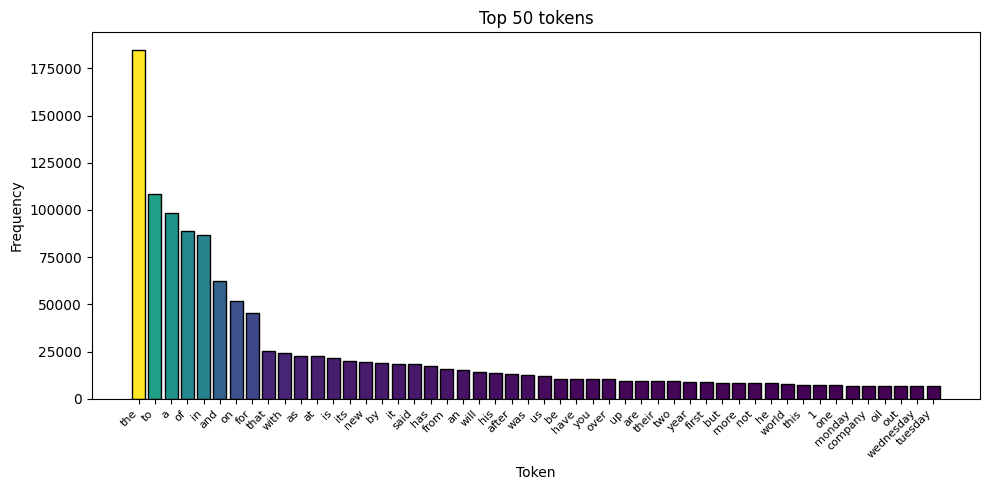

In [10]:
# Plot the top 50 sentences
sorted_vocab = sorted(vocab_counts.items(), key=lambda x: x[1], reverse=True)
top_50_frequency = jnp.array([x[1] for x in sorted_vocab[:50]])

cmap = plt.cm.viridis
norm = lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)

colors = cmap(norm(top_50_frequency))

tokens = [x[0] for x in sorted_vocab[:50]]
freqs = [x[1] for x in sorted_vocab[:50]]

plt.figure(figsize=(10,5))

plt.bar(tokens, freqs, color=colors, edgecolor="black", width=0.8)

plt.xlabel("Token")
plt.ylabel("Frequency")
plt.title("Top 50 tokens")
plt.xticks(rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

In [11]:
def tokenize_and_encode(example):
    ids = [token_to_id.get(tok, UNK_ID) for tok in tokenize(example["text"])]
    ids = [BOS_ID] + ids + [EOS_ID]
    ids = ids[:seq_len + 1]

    if len(ids) < seq_len + 1:
        ids += [PAD_ID] * (seq_len + 1 - len(ids))

    return {"x": ids[:-1], "y": ids[1:]}

# Apply tokenization to train,validation and test dataset

train_ds = train_ds.map(tokenize_and_encode, num_proc=4)
val_ds = val_ds.map(tokenize_and_encode, num_proc=4)
test_ds = test_ds.map(tokenize_and_encode, num_proc=4)

x_train_ids = jnp.array(train_ds["x"], dtype=jnp.int32)
y_train_ids = jnp.array(train_ds["y"], dtype=jnp.int32)

x_val_ids = jnp.array(val_ds["x"], dtype=jnp.int32)
y_val_ids = jnp.array(val_ds["y"], dtype=jnp.int32)

x_test_ids = jnp.array(test_ds["x"], dtype=jnp.int32)
y_test_ids = jnp.array(test_ds["y"], dtype=jnp.int32)

Map (num_proc=4):   0%|          | 0/108000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Map (num_proc=4):   0%|          | 0/12000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Map (num_proc=4):   0%|          | 0/7600 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


In [12]:
# Print 5 random samples from the training set after numerical tokenization
for i in range(5):
    idx = jrand.randint(jrand.PRNGKey(i), 1, 0, len(train_ds))
    sample = train_ds[idx]["x"]

    print(f"Sample {i+1}:\n Text: {sample}\n")

Sample 1:
 Text: [[2, 6090, 1404, 6022, 24, 8575, 486, 62, 1930, 2969, 107, 11772, 25, 107, 13456, 443, 4207, 847, 2482, 437, 14515, 48, 2362, 950, 437, 7602, 210, 71, 3961, 1, 1792, 251, 14516, 107, 10883, 495, 1667, 941, 900, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

Sample 2:
 Text: [[2, 2499, 25, 3721, 3957, 2095, 355, 29, 409, 2095, 111, 604, 299, 1031, 2501, 2499, 630, 25, 3721, 3957, 48, 803, 900, 205, 2808, 630, 6674, 1, 1, 107, 1, 48, 405, 7463, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

Sample 3:
 Text: [[2, 1668, 311, 507, 281, 378, 6070, 1730, 6070, 630, 9219, 158, 251, 311, 507, 107, 3334, 39, 769, 1259, 1467, 205, 17467, 2028, 176, 5538, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

Sample 4:
 Text: [[2, 39, 1, 4192, 780, 107, 2759, 835, 1, 83, 29, 1, 789, 2702, 241, 232, 4598, 29, 1537, 1, 39, 1, 4192, 48, 707, 521, 6060, 207, 107, 8673, 10972, 4962, 1070, 1, 780, 25, 2225, 459, 2569, 6134, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

### Exercise 1: KV Cache (mandatory)

**KV caching** is a mechanism implemented in autoregressive transformer models, wherein previous key and value computations are stored and reused when predicting a new token (see book, Chapter 11) and [this blog post](https://magazine.sebastianraschka.com/p/coding-the-kv-cache-in-llms).

> 🟨 Required reading before proceeding: [https://jax-ml.github.io/scaling-book/inference/](https://jax-ml.github.io/scaling-book/inference/).

**TODO**: Write and test a variant of multi-head attention with an internal KV cache mechanism. This is mostly didactical, so you should not concern too much with speed and efficiency (very difficult to achieve in practice).

💡 *Hint*: Start by coding the MHA layer and then add the KV Caching mechanism.

✍ **DESCRIPTION OF THE CODE**

*Provide a description of what you are implementing, both as text and in the comments of the code. Importantly, describe carefully the design of the layer. Train a model with the new layer and show some plots to visualize the training (e.g., loss curves, perplexity, ...) on the data you loaded before.*

## Model Description

To do this task, a smaller version of [GPT-1](https://huggingface.co/openai-community/openai-gpt#model-details) was used **[1]**. In particular the model was configured with 6M parameters to comply with the resource constraints of T4 GPU on Google Colab. It is composed of sinusoidal positional encodings, a stack of Transformer blocks and a final linear projection layer for next token prediction. It returns up to three outputs:

* The model's logits of shape (batch_size, seq_length, model_size).
* Key-Value Cache when `use_cache = True`.
* Attention weights when `return_weights = True`, to investigate the specific model's activations across tokens, revealing which ones influence each other during text generation.

Each Transformer block applies a fixed dropout rate of 0.1, while the overall model dropout rate is configurable as an input parameter.

---

### Positional Encoding

To remember the token order information, this technique is used.
The sinusoidal positional encoding **[2]** is applied in the model in the following way:

$$
\text{PE}_\text{(pos,2i)} = \sin\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)
\\[5 pt]
$$

$$
\text{PE}_\text{(pos,2i+1)} = \cos\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)
\\[5 pt]
$$

$$\small \text{where } d_{\text{model}} \text{ is model embedding dimensionality}$$

---

### Transformer Block

Each Transformer block consists of a Multi-Head Attention mechanism, where multiple attention heads run in parallel to capture different types of relationships within the input sequence. Each head learns different queries (Q), keys (K) and values (V), allowing the model to learn distinct semantic representation.**[2]**

Formally, given input tensors Q, K and V with shape: (batch_size, num_heads, seq_length, head_dim).

The scaled dot-product attention for a single head is defined as:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^{T}}{\sqrt{d_k}}\right)V
\\[15pt]
\text{MultiHead}(Q, K, V) = \text{concat}\left(head_1,head_2,..,head_h\right)W_o
$$

$$
\small\text{where } head_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)
\\[5pt]
$$

The Multi-Head Attention output of each Transformer block is then processed through a fully connected feed-forward network **[2]**.

It consists of two linear transformations with a GELU activation function between them.

A residual connection is also applied to preserve the original input information and ensure stable gradient flow during training, mitigating vanishing and exploding gradient issues.

$$
\text{FFN}(x) = \text{Linear}_2(\text{GELU}(\text{Linear}_1(x)))
$$

$$
\text{Output} = x + \text{FFN}(x)
$$

---

### Cache

A **KV cache** is added in each Transformer block when `use_cache = True`. Instead of recomputing keys and values for all previous tokens at every step, the model stores past key (K), value (V) and updates them by concatenating with the new key and value tensors. This reduces computational cost during autoregressive generation, as attention is computed only for the latest token against the cached history **[3]**.

---

## Training

The model was trained over 20 epochs to ensure stable convergence, using the *Cross-Entropy loss* and *Perplexity* defined as:

$$
\text{CE}(y, \hat{y}) = - \frac{1}{N} \sum_{i=1}^{N} y_i \log(\hat{y}_i)
$$

$$
\text{PPL}(y) = \exp(\text{CE}(y, \hat{y}))
\\[5 pt]
$$

The model was trained with the following hyper-parameters configuration:

    d_model = 128,
    num_heads = 4,
    num_layers = 8,
    vocab_size ≈ 18000,
    dropout_rate = 0.3
  
This configuration balances expressivity and efficiency, enabling meaningful representation learning within Google Colab's resource limits usage.
The model's depth, vocabulary size, and dropout enhance generalization while reducing complexity.

The model parameters were optimized using the AdamW optimizer with:

*   learning_rate = 1e-3
*   weight_decay = 1e-4

To monitor performance during training, the model was evaluated on the validation set every 4 epochs using *Top-k Accuracy*, which measures whether the correct token appears within the top k predictions at each sequence position.

---

## Sources

> 1. [Improving Language Understanding by Generative Pre-Training](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf)

> 2. [Attention Is all You Need](http://arxiv.org/abs/1706.03762)

> 3. [Understanding and Coding the KV Cache in LLMs from Scratch](https://magazine.sebastianraschka.com/p/coding-the-kv-cache-in-llms)

In [13]:
epochs = 20
batch_size = 128
# Initialize a dictionary to store training metrics to track all values over the epochs
metrics = {"train_losses":[],"val_losses":[],"top-1-accuracy":[],"top-3-accuracy":[],"top-5-accuracy":[]}

KEY = jrand.PRNGKey(42)
n_train = x_train_ids.shape[0]
train_batches = n_train // batch_size

model_key = jrand.PRNGKey(0)

# Initialize the model
model = GPT1(
    d_model=128,
    num_heads=4,
    num_layers=8,
    vocab_size=len(vocabulary),
    key=model_key,
    dropout_rate=0.3,
    return_attention_weights=True)

print(f"Number of parameters: {model.num_params()/1e6:.2f} millions")

optimizer = optax.adamw(learning_rate=1e-3, weight_decay=1e-4)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

Number of parameters: 6.08 millions


In [14]:
def loss_fn(my_model, x, y, key, pad_id: int = 0):
    out = my_model(x, key=key, inference=False)
    return cross_entropy_loss(out.logits, y, pad_id = pad_id)

# Define Training steps
@eqx.filter_jit
def train_step(my_model, state, x_ids, y_ids, key, pad_id: int = 0):
    loss, grads = eqx.filter_value_and_grad(loss_fn)(my_model, x_ids, y_ids, key, pad_id)
    updates, state = optimizer.update(grads, state, my_model)
    my_model = eqx.apply_updates(my_model, updates)
    return my_model, state, loss

In [15]:
# Training
for epoch in range(1, epochs + 1):
    epoch_loss = 0.0
    batch_count = 0

    # Shuffle once per epoch, then iterate all full batches.
    KEY, key_perm, key_steps = jrand.split(KEY,3)
    step_keys = jrand.split(key_steps, train_batches)

    perm = jrand.permutation(key_perm, n_train)
    x_shuffled = x_train_ids[perm]
    y_shuffled = y_train_ids[perm]

    for i in range(0,train_batches):

        xb = x_shuffled[i * batch_size:(i + 1) * batch_size]
        yb = y_shuffled[i * batch_size:(i + 1) * batch_size]

        model, opt_state, loss = train_step(model, opt_state, xb, yb, step_keys[i], pad_id = PAD_ID)
        epoch_loss += loss

    avg_loss = epoch_loss / train_batches
    val_loss = compute_val_loss(model, x_val_ids, y_val_ids, pad_id = PAD_ID, batch_size=batch_size)

    metrics["train_losses"].append(avg_loss)
    metrics["val_losses"].append(val_loss)

    print(f"Epoch {epoch}/{epochs} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f}\n"
            f"Train Perplexity: {jnp.exp(avg_loss):.4f} | Val Perplexity: {jnp.exp(val_loss):.4f}")

    if epoch % 4 == 0:
        top1 = top_k_accuracy(model, x_val_ids, y_val_ids, k=1, batch_size=batch_size)
        top3 = top_k_accuracy(model, x_val_ids, y_val_ids, k=3, batch_size=batch_size)
        top5 = top_k_accuracy(model, x_val_ids, y_val_ids, k=5, batch_size=batch_size)

        metrics["top-1-accuracy"].append(float(top1))
        metrics["top-3-accuracy"].append(float(top3))
        metrics["top-5-accuracy"].append(float(top5))

        print(f"Top-1-Accuracy: {top1:.4f} | Top-3-Accuracy: {top3:.4f} | Top-5-Accuracy: {top5:.4f}")


Epoch 1/20 | Train Loss: 6.6504 | Val Loss: 5.7894
Train Perplexity: 773.0999 | Val Perplexity: 326.8172
Epoch 2/20 | Train Loss: 5.7083 | Val Loss: 5.3186
Train Perplexity: 301.3536 | Val Perplexity: 204.0929
Epoch 3/20 | Train Loss: 5.3804 | Val Loss: 5.0898
Train Perplexity: 217.0987 | Val Perplexity: 162.3533
Epoch 4/20 | Train Loss: 5.1887 | Val Loss: 4.9478
Train Perplexity: 179.2331 | Val Perplexity: 140.8706
Top-1-Accuracy: 0.2132 | Top-3-Accuracy: 0.3357 | Top-5-Accuracy: 0.3953
Epoch 5/20 | Train Loss: 5.0591 | Val Loss: 4.8529
Train Perplexity: 157.4461 | Val Perplexity: 128.1164
Epoch 6/20 | Train Loss: 4.9643 | Val Loss: 4.7810
Train Perplexity: 143.2100 | Val Perplexity: 119.2211
Epoch 7/20 | Train Loss: 4.8910 | Val Loss: 4.7357
Train Perplexity: 133.0825 | Val Perplexity: 113.9448
Epoch 8/20 | Train Loss: 4.8308 | Val Loss: 4.6853
Train Perplexity: 125.3089 | Val Perplexity: 108.3381
Top-1-Accuracy: 0.2356 | Top-3-Accuracy: 0.3656 | Top-5-Accuracy: 0.4273
Epoch 9/20 | T

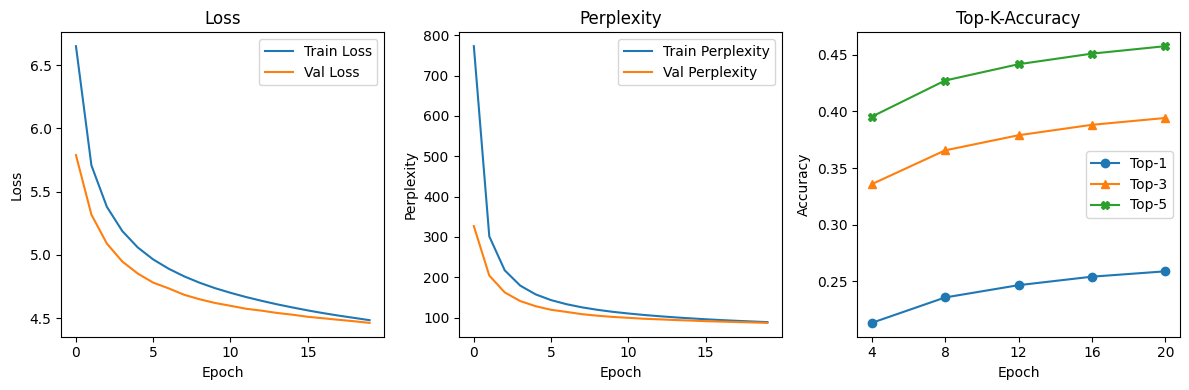

In [16]:
# Plot metrics
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# Loss
axs[0].plot(metrics["train_losses"], label="Train Loss")
axs[0].plot(metrics["val_losses"], label="Val Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].set_title("Loss")
axs[0].legend()

# Perplexity
axs[1].plot(jnp.exp(jnp.array(metrics["train_losses"])), label="Train Perplexity")
axs[1].plot(jnp.exp(jnp.array(metrics["val_losses"])), label="Val Perplexity")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Perplexity")
axs[1].set_title("Perplexity")
axs[1].legend()

# Top-k-Accuracy over epochs
axs[2].plot(list(range(4,epochs + 1,4)),metrics["top-1-accuracy"],marker='o', label="Top-1")
axs[2].plot(list(range(4,epochs + 1,4)),metrics["top-3-accuracy"],marker='^', label="Top-3")
axs[2].plot(list(range(4,epochs + 1,4)),metrics["top-5-accuracy"],marker='X', label="Top-5")
axs[2].set_xlabel("Epoch")
axs[2].set_xticks(list(range(4,epochs + 1,4)))
axs[2].set_ylabel("Accuracy")
axs[2].set_title("Top-K-Accuracy")
axs[2].legend()

plt.tight_layout()
plt.show()

In [17]:
"""
Optional: save the model state after the traning
Remove the comments to save the model history.
"""

# import os
# save_directory = "/content/drive/MyDrive/NNDS"
# os.makedirs(save_directory,exist_ok=True)

# model_path = os.path.join(save_directory, "model.eqx")

# # Save
# eqx.tree_serialise_leaves(model_path, model)

# # Re-initialize Model
# model = GPT1(
#     d_model=128,
#     num_heads=4,
#     num_layers=8,
#     vocab_size=len(vocabulary),
#     key=model_key,
#     dropout_rate=0.3,
#     return_attention_weights=True)

# model = eqx.tree_deserialise_leaves(model_path, model)

'\nOptional: save the model state after the traning\nRemove the comments to save the model history.\n'

In [18]:
# Compute Test metrics
test_loss = compute_val_loss(model, x_test_ids, y_test_ids, batch_size=batch_size)

test_top1 = top_k_accuracy(model, x_test_ids, y_test_ids, k=1, batch_size=batch_size)
test_top3 = top_k_accuracy(model, x_test_ids, y_test_ids, k=3, batch_size=batch_size)
test_top5 = top_k_accuracy(model, x_test_ids, y_test_ids, k=5, batch_size=batch_size)

print(f"Test Loss: {test_loss:.4f} | Test Perplexity: {jnp.exp(test_loss):.4f} | Top-1-Accuracy: {test_top1:.4f} | Top-3-Accuracy: {test_top3:.4f} | Top-5-Accuracy: {test_top5:.4f}")

Test Loss: 4.4628 | Test Perplexity: 86.7299 | Top-1-Accuracy: 0.2587 | Top-3-Accuracy: 0.3937 | Top-5-Accuracy: 0.4578


In [19]:
def mask_token(logits):
    for token_id in [UNK_ID, PAD_ID, BOS_ID]:
        logits = logits.at[:, :, token_id].set(-jnp.inf)
    return logits

def decode_ids(ids):
    tokens = (id_to_token[int(i)] for i in ids)
    out = []
    for t in tokens:
        if t == "<EOS>":
          break
        if t not in {"<PAD>", "<BOS>"}:
            out.append(t)
    return " ".join(out)

def apply_repetition_penalty(logits, generated_ids, penalty=1.2):

    mask = jnp.zeros_like(logits)
    mask = mask.at[jnp.array(generated_ids)].set(1.0)

    penalty_condition = jnp.where(logits > 0, logits / penalty, logits * penalty)

    return jnp.where(mask, penalty_condition, logits)

In [20]:
def generate_text(model, prompt_text, max_new_tokens=40, temperature=1.0, seed=42, penalty=1.0, use_cache=True):
    # Convert prompt text into token ids and truncate to seq_len
    ids = [BOS_ID] + [token_to_id.get(tok, UNK_ID) for tok in tokenize(prompt_text)]
    ids = ids[:seq_len]
    generation_key = jrand.PRNGKey(seed)

    input_seq = jnp.array(ids, dtype=jnp.int32)[None, :]

    if use_cache:
    # Prefill step: processes prompt and saves the key-value projections in a cache
      logits, cache, _ = model(input_seq, inference=True, use_cache=True, cache=None)

    cache_sizes = []
    start = time.time()

    for _ in range(max_new_tokens):
        if not use_cache:
          input_seq = jnp.array(ids[-seq_len:], dtype=jnp.int32)[None, :]
          logits, _, _ = model(input_seq, inference=True)

        logits = mask_token(logits)
        # Extract last-token logits
        next_token_logits = logits[0, -1, :]
        next_token_logits = apply_repetition_penalty(next_token_logits, ids, penalty=penalty)

        # Convert logits to probability distribution and sample next token
        probs = jax.nn.softmax(next_token_logits / temperature)
        generation_key, subkey = jrand.split(generation_key)

        next_id = int(jrand.choice(subkey, probs.shape[-1], p=probs))
        ids.append(next_id)
        if next_id == EOS_ID:
            break

        if use_cache:
        # Generate next token using KV cache
            logits, cache, _ = model(jnp.array([[next_id]], dtype=jnp.int32), inference=True, use_cache=True, cache=cache)
            total_tokens = sum(k.shape[1] for k, v in cache)
            cache_sizes.append(total_tokens)

    end = time.time()

    if use_cache:
    # Visualize Cache growth
      plt.figure(figsize=(8,4))
      plt.plot(range(len(cache_sizes)), cache_sizes, marker='o', label="Cache size")
      plt.xlabel("Generated token index")
      plt.ylabel("Cache size per l")
      plt.title("Cache size per token generated")
      plt.legend()
      plt.grid(linestyle='--', linewidth=0.5)
      plt.show()

    print(f"Time taken: {end - start:.2f} seconds")
    return decode_ids(ids)

In [21]:
# Four generic prompts, one for each News category
prompts = ["International tensions increase","Red Sox defeat Yankees","Markets show mixed signals","Microsoft announces"]

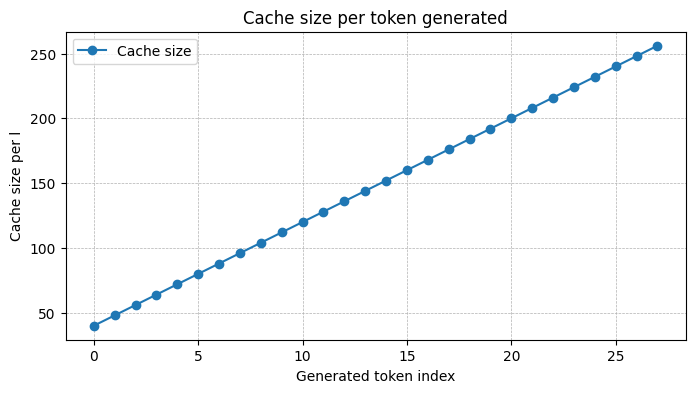

Time taken: 10.98 seconds
1. Prompt: International tensions increase
international tensions increase in iraq on elections the world largest military and iraqi delegates have warned that a new version of its troops will be used by iraqi president saddam hussein
Number of tokens generated: 28



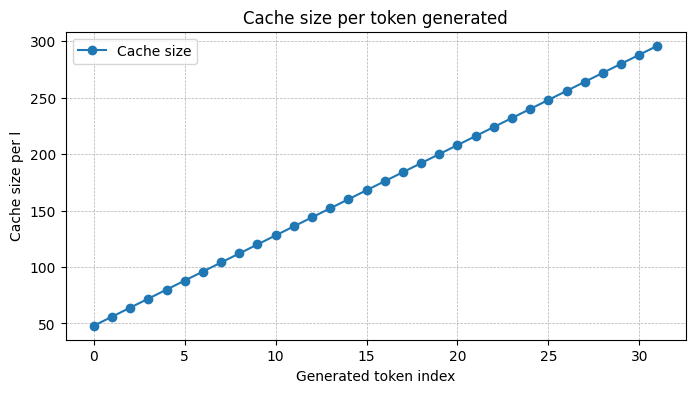

Time taken: 12.27 seconds
2. Prompt: Red Sox defeat Yankees
red sox defeat yankees 4 3 in game 2 of alcs boston the new york yankees have won their first major league baseball playoff series with a 7 1 victory over the tampa bay devil rays
Number of tokens generated: 32



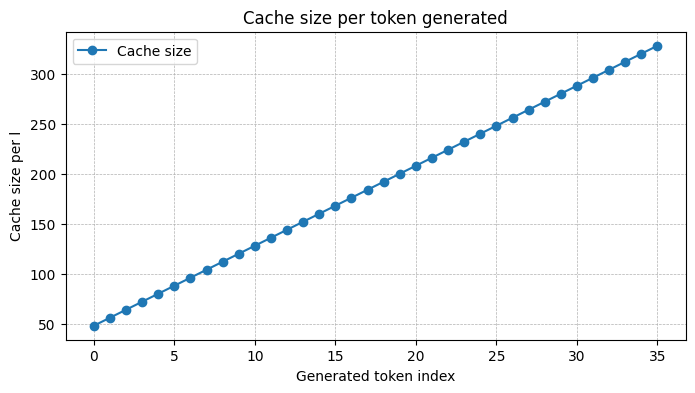

Time taken: 13.80 seconds
3. Prompt: Markets show mixed signals
markets show mixed signals dollar higher new york the dollar remained sharply on friday following a report that the us economy grew at an annual rate of 1 7 percent in september as investors took profits from a sharp rise
Number of tokens generated: 36



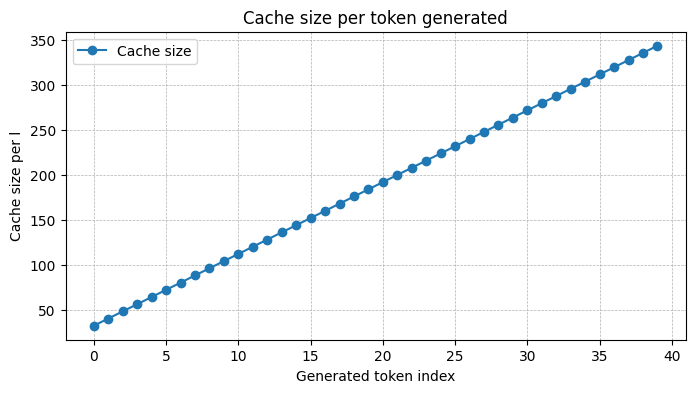

Time taken: 15.32 seconds
4. Prompt: Microsoft announces
microsoft announces new windows xp starter edition the latest version of its visual system to be released in 2006 microsoft is set to announce on wednesday that it has announced a new product for the next generation of a low cost software
Number of tokens generated: 40



In [31]:
for index,prompt in enumerate(prompts):
    generated_text = generate_text(model, prompt, max_new_tokens = 50, temperature = 0.50, use_cache = True, penalty = 1.4)
    num_tokens_generated = len(tokenize(generated_text)) - len(tokenize(prompt))
    print(f"{index+1}. Prompt: {prompt}\n{generated_text}\nNumber of tokens generated: {num_tokens_generated}\n")


In [32]:
for index,prompt in enumerate(prompts):
    generated_text = generate_text(model, prompt, max_new_tokens = 50, temperature = 0.50, use_cache=False, penalty = 1.4)
    num_tokens_generated = len(tokenize(generated_text)) - len(tokenize(prompt))
    print(f"{index+1}. Prompt: {prompt}\n{generated_text}\nNumber of tokens generated: {num_tokens_generated}\n")

Time taken: 11.30 seconds
1. Prompt: International tensions increase
international tensions increase in iraq on elections the world largest military and iraqi delegates have warned that a new version of its troops will be used by iraqi president saddam hussein
Number of tokens generated: 28

Time taken: 12.90 seconds
2. Prompt: Red Sox defeat Yankees
red sox defeat yankees 4 3 in game 2 of alcs boston the new york yankees have won their first major league baseball playoff series with a 7 1 victory over the tampa bay devil rays
Number of tokens generated: 32

Time taken: 14.37 seconds
3. Prompt: Markets show mixed signals
markets show mixed signals dollar higher new york the dollar remained sharply on friday following a report that the us economy grew at an annual rate of 1 7 percent in september as investors took profits from a sharp rise
Number of tokens generated: 36

Time taken: 16.07 seconds
4. Prompt: Microsoft announces
microsoft announces new windows xp starter edition the lates

### Exercise 2: KV Cache compression (4 points)

**KV cache compression** algorithms try to dinamically reduce the size of the KV cache by, e.g., removing key/value pairs, or compressing them to a reduced set of tokens. See [this paper](https://arxiv.org/abs/2406.11430) for an introduction, and the [kvpress](https://github.com/NVIDIA/kvpress) library from NVIDIA for practical implementations (in PyTorch).

**TODO**: Reimplement (and test) one of the methods from the KVPress library (e.g., `KnormPress`).

✍ **DESCRIPTION OF THE CODE**

*Provide a description of what you are implementing, both as text and in the comments of the code. When feasible, show some statistics on the layer (e.g. on the resulting size of the KV cache and/or which tokens tend to be selected for exclusion).*

## *L2* Compression Algorithm

During text generation, the model Key-Value cache is dynamically updated using two parameters:

- `prune_after`: threshold on the sequence length beyond which cache compression is applied;
- `compress_ratio`: fraction of tokens to retain after compression to reduce memory usage during generation.

---

### Steps

This algorithm selects the most relevant tokens based on the *L2* norm of the key vectors. In detail:

1. Compute the *L2* norm of each token representation
2. Average the norms across attention heads
3. Rank tokens based on their scores and retain only the most informative ones, defined by:

$$
\text{Tokens to keep} = \max(1, \text{compress ratio} \cdot \text{sequence length})
$$

Tokens with lower norms are assumed to carry more information and are therefore preserved in the cache.**[1]**

---

### Considerations

- For short sequences (`sequence length < prune_after`), compression is not applied.
- Cache compression may remove useful long-range dependencies such as details about specific events in scientific, technological, or sports domains.

---

## Implementation

The algorithm was integrated into the text generation pipeline and is applied when `compress_ratio != 1.0`.  
Cache compression is triggered when the sequence length exceeds the `prune_after` threshold, using `compress_ratio = 0.70`.

---

## Source

> 1. [A Simple and Effective L2 Norm-Based Strategy for KV Cache Compression](https://arxiv.org/abs/2406.11430)

In [24]:
def l2_compress(cache, compress_ratio = 1.0, prune_after = 8):
    new_cache = []
    # Iterate over key (K) and value (V) with shape: (batch, seq_len, heads, head_dim)
    for k, v in cache:
        seq_len = k.shape[1]

        if seq_len < prune_after:
            new_cache.append((k, v))
            continue

        tokens_to_keep = max(1, int(compress_ratio * seq_len))

        # compute L2 norm per token and average across heads
        token_norms = jnp.linalg.norm(k, axis=-1)
        token_norms_mean = jnp.mean(token_norms, axis=-1)

        # Sort indices in ascending order to select the lowest-norm tokens
        sorted_indices = jnp.argsort(token_norms_mean, axis=1)
        top_indices = sorted_indices[:, :tokens_to_keep]
        top_indices = jnp.sort(top_indices, axis=1)

        # Broadcast idx to (batch, tokens_to_keep, heads, head_dim) for take_along_axis
        idx = top_indices[:, :, None, None]
        k_new = jnp.take_along_axis(k, idx, axis=1)
        v_new = jnp.take_along_axis(v, idx, axis=1)

        new_cache.append((k_new, v_new))

    return new_cache

In [25]:
def generate_text_compress(model, prompt_text, max_new_tokens=40,temperature=1.0, penalty=1.2, seed=42, ratio = 1.0, cache_cap: int = 1024):
    # Convert prompt text into token ids and truncate to seq_len
    ids = [BOS_ID] + [token_to_id.get(tok, UNK_ID) for tok in tokenize(prompt_text)]
    ids = ids[:seq_len]
    generation_key = jrand.PRNGKey(seed)

    input_seq = jnp.array(ids, dtype=jnp.int32)[None, :]

    # Prefill step: processes prompt and saves the key-value projections in a cache
    logits, cache, _ = model(input_seq, inference=True, use_cache=True, cache=None)

    cache_sizes = []
    start = time.time()

    for _ in range(max_new_tokens):
        logits = mask_token(logits)
        # Extract last-token logits
        next_token_logits = logits[0, -1, :]
        next_token_logits = apply_repetition_penalty(next_token_logits, ids, penalty=penalty)

        # Convert logits to probability distribution and sample next token
        probs = jax.nn.softmax(next_token_logits / temperature)
        generation_key, subkey = jrand.split(generation_key)

        next_id = int(jrand.choice(subkey, probs.shape[-1], p=probs))
        ids.append(next_id)
        if next_id == EOS_ID:
            break
        # Generation + cache update + L2 cache compression
        logits, cache, attn_weights = model(jnp.array([[next_id]], dtype=jnp.int32),inference=True, use_cache=True, cache=cache)
        if ratio != 1.0:
          cache = l2_compress(cache, compress_ratio=ratio, prune_after = cache_cap)

        total_tokens = sum(k.shape[1] for k, v in cache)
        cache_sizes.append(total_tokens)

    end = time.time()

    # Visualize Cache growth with L2 compression
    plt.figure(figsize=(8,4))
    plt.plot(range(len(cache_sizes)), cache_sizes, marker='o')
    plt.xlabel("Generated token index")
    plt.ylabel("KV cache size")
    plt.title("KV cache size per token generated (single layer)")
    plt.grid(linestyle='--', linewidth=0.5)
    plt.show()

    last_attn = attn_weights
    print(f"Time taken: {end - start:.2f} seconds")

    return decode_ids(ids), last_attn

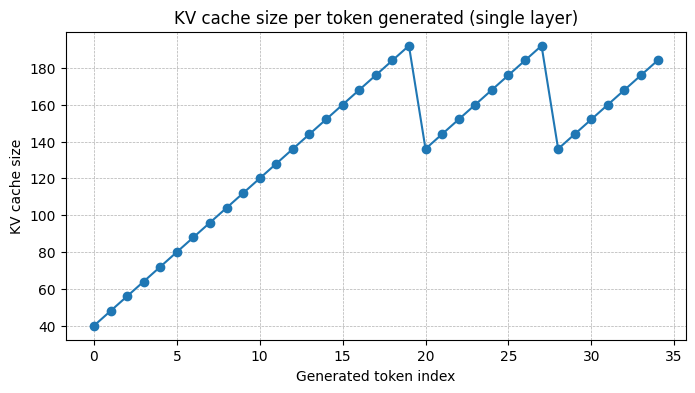

Time taken: 13.73 seconds
1. Prompt: International tensions increase
international tensions increase in iraq on elections the world largest military and iraqi delegates have warned that a new version of its troops will be delayed january 30 for the next three years of elections to replace president
Number of tokens generated: 35



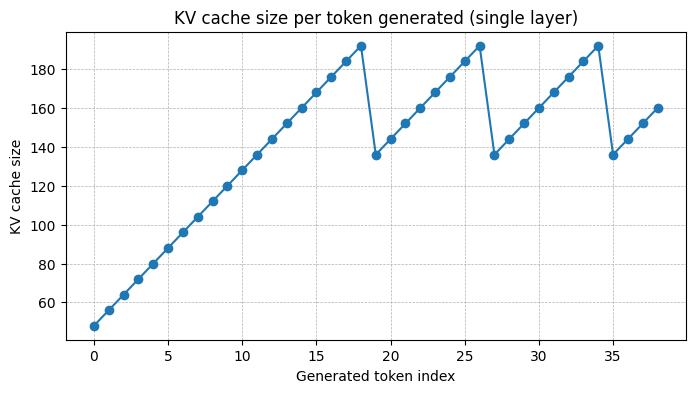

Time taken: 15.08 seconds
2. Prompt: Red Sox defeat Yankees
red sox defeat yankees 4 3 in game 2 of alcs boston the new york yankees have won their first major league baseball playoff series after a four game sweep of the american league championship series the cardinals were in the world series
Number of tokens generated: 39



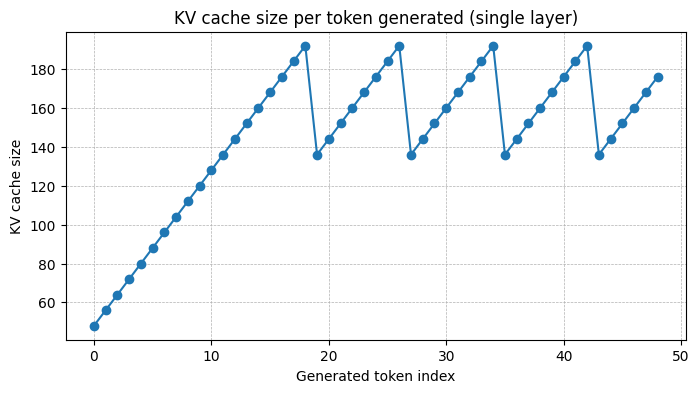

Time taken: 23.04 seconds
3. Prompt: Markets show mixed signals
markets show mixed signals dollar higher new york the dollar remained sharply on friday following a report that the us economy grew at an annual rate of 1 5 percent in september has been boosted by a slide in you interest rates could cast their lowest level since march above 1 7 percent
Number of tokens generated: 49



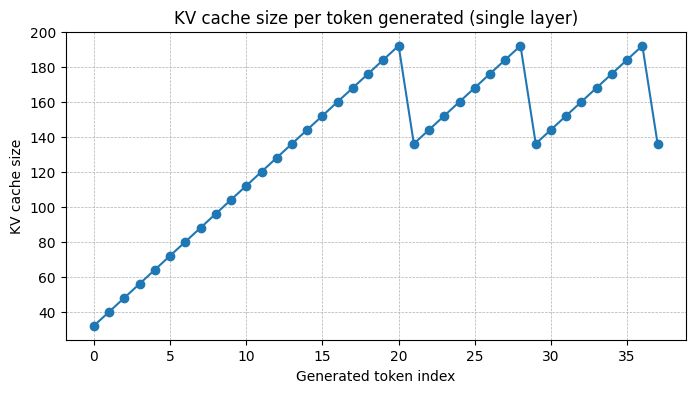

Time taken: 14.22 seconds
4. Prompt: Microsoft announces
microsoft announces new windows xp starter edition the latest version of its visual system to be released in 2006 microsoft is set to announce on a new server and will let us users in the next generation of the world
Number of tokens generated: 38



In [26]:
storage_l2_cache = []
storage_attn = []

for index,prompt in enumerate(prompts):
    generated_text, last_attn = generate_text_compress(model, prompt, max_new_tokens = 50, temperature=0.50, penalty = 1.4 ,ratio = 0.70, cache_cap = 25)
    num_tokens_generated = len(tokenize(generated_text)) - len(tokenize(prompt))
    print(f"{index+1}. Prompt: {prompt}\n{generated_text}\nNumber of tokens generated: {num_tokens_generated}\n")

    storage_l2_cache.append(generated_text)
    storage_attn.append(last_attn)

### **Attention Weights Visualization using Bar Plots**

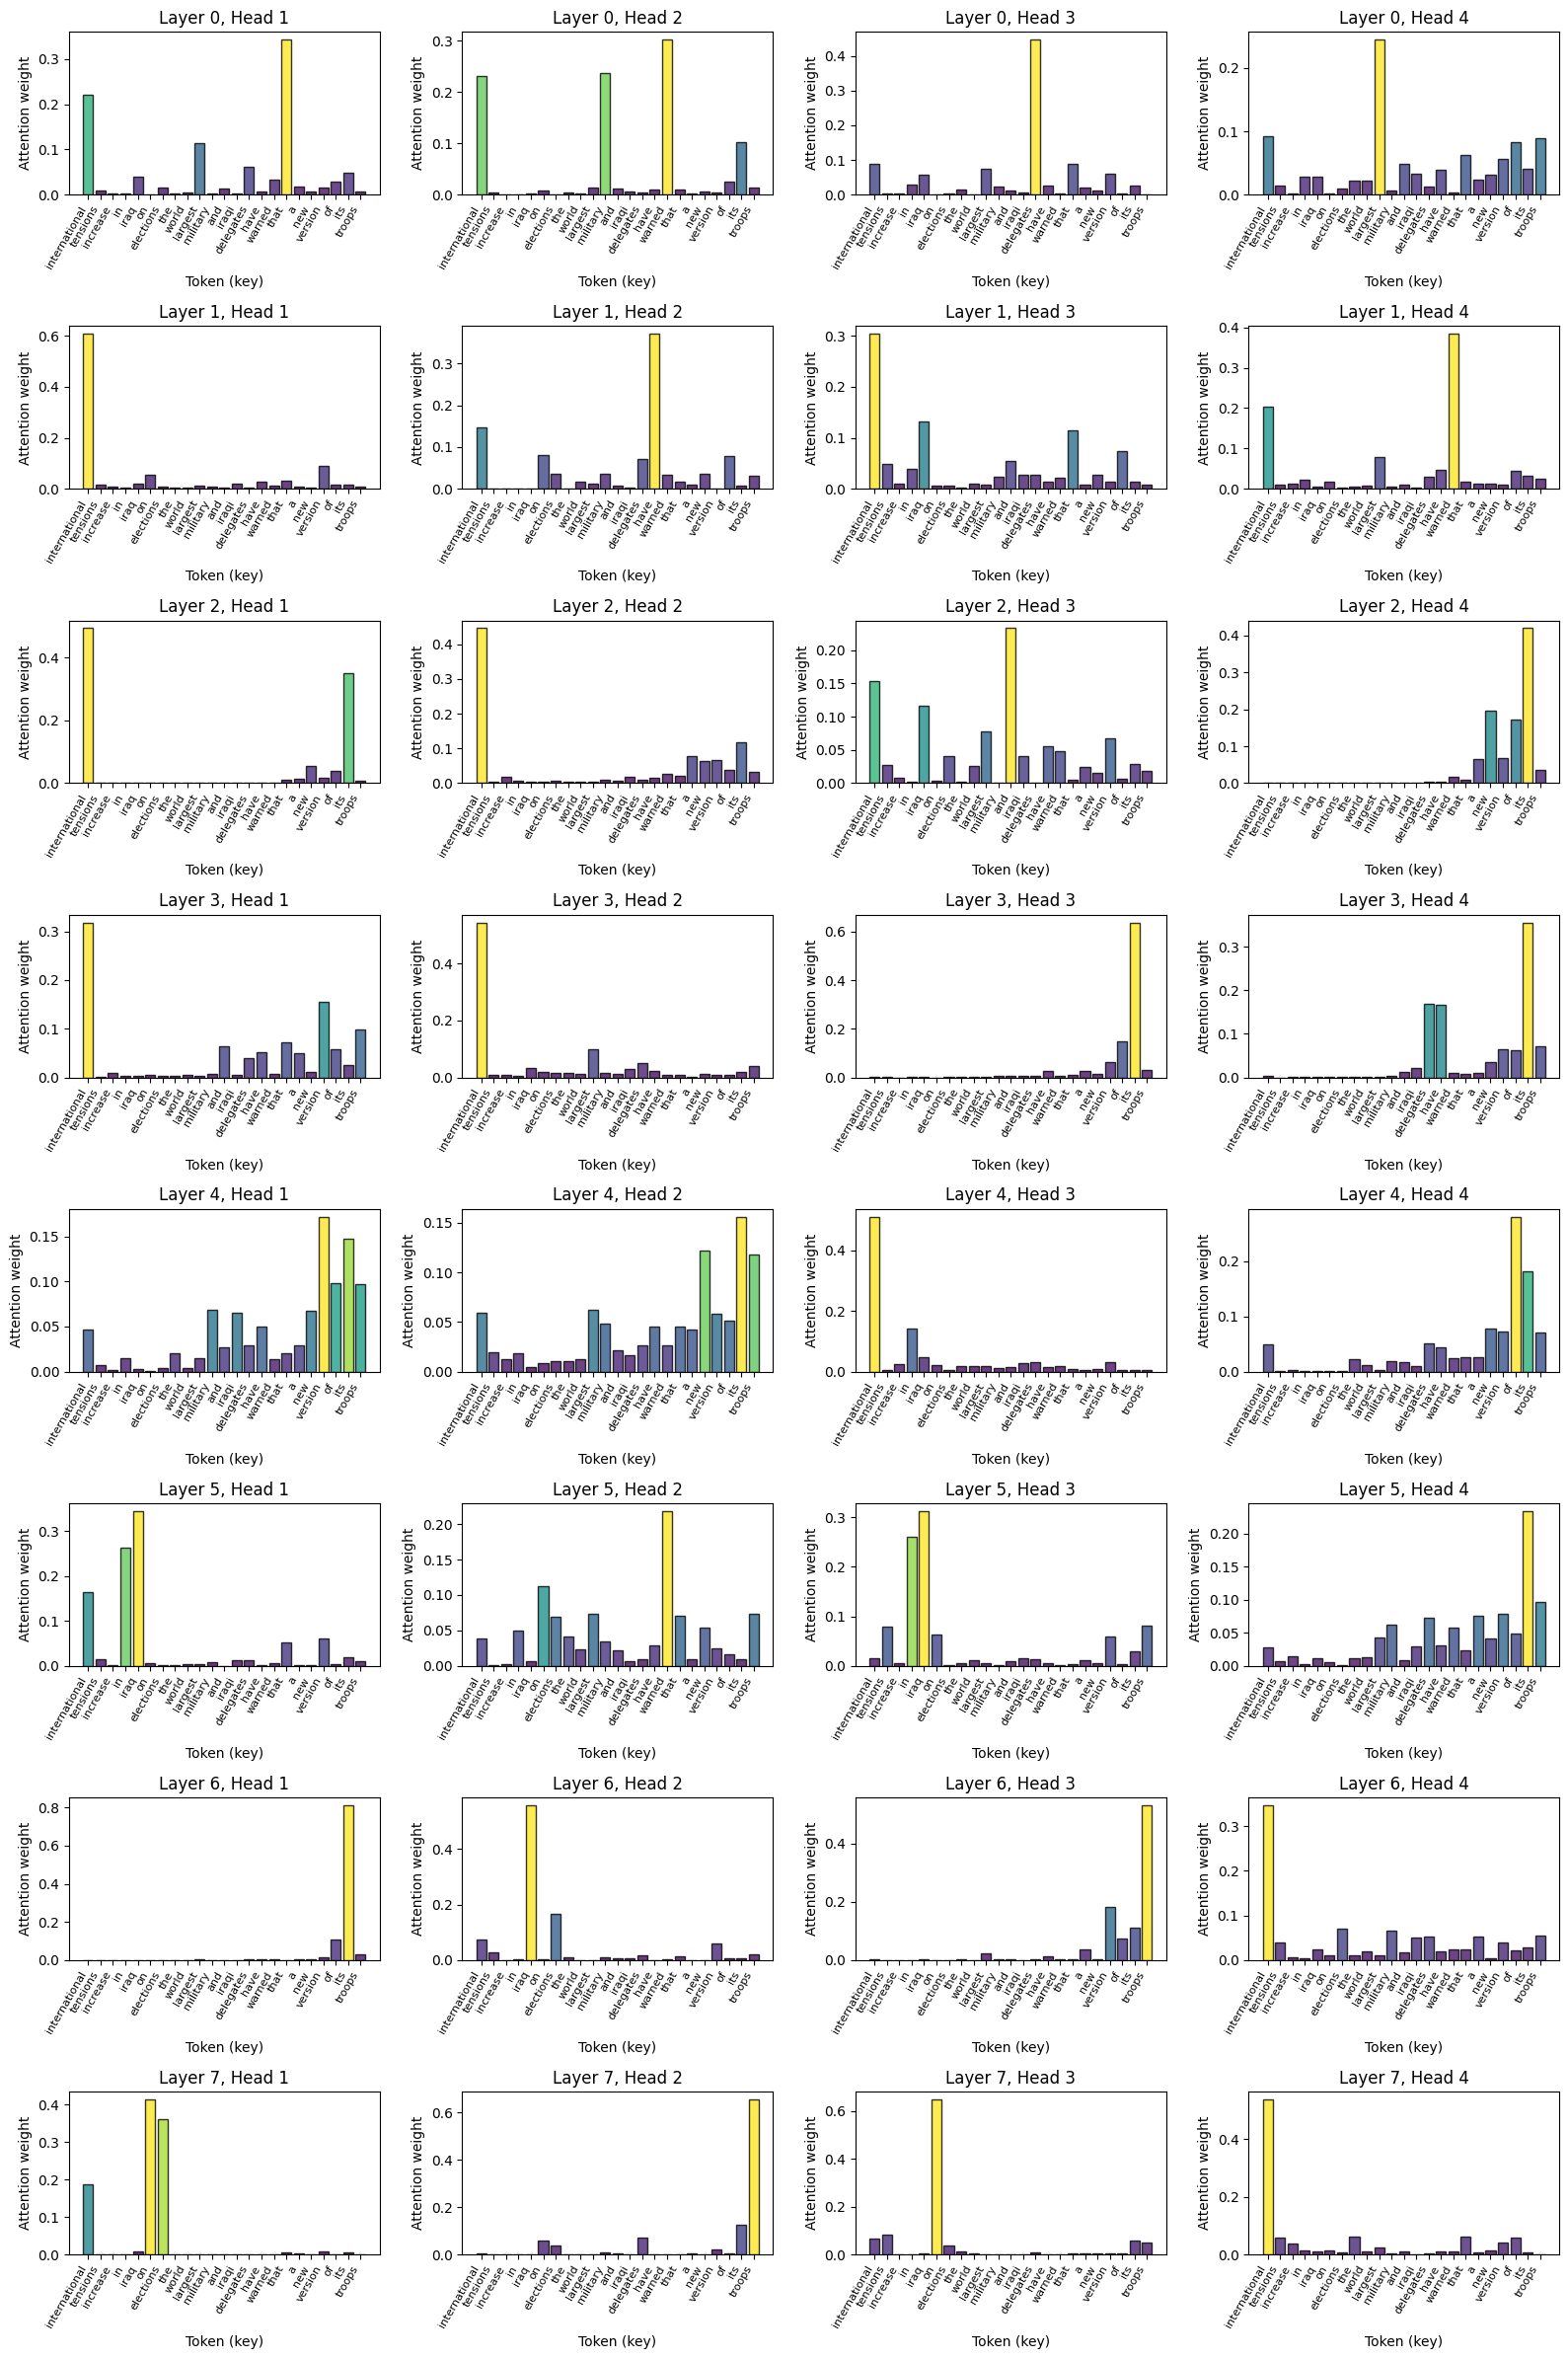

In [27]:
# Plot the attention weights for the first prompt
plot_attention_bar(storage_attn[0], storage_l2_cache[0].split(),num_heads=4, num_layers=8)

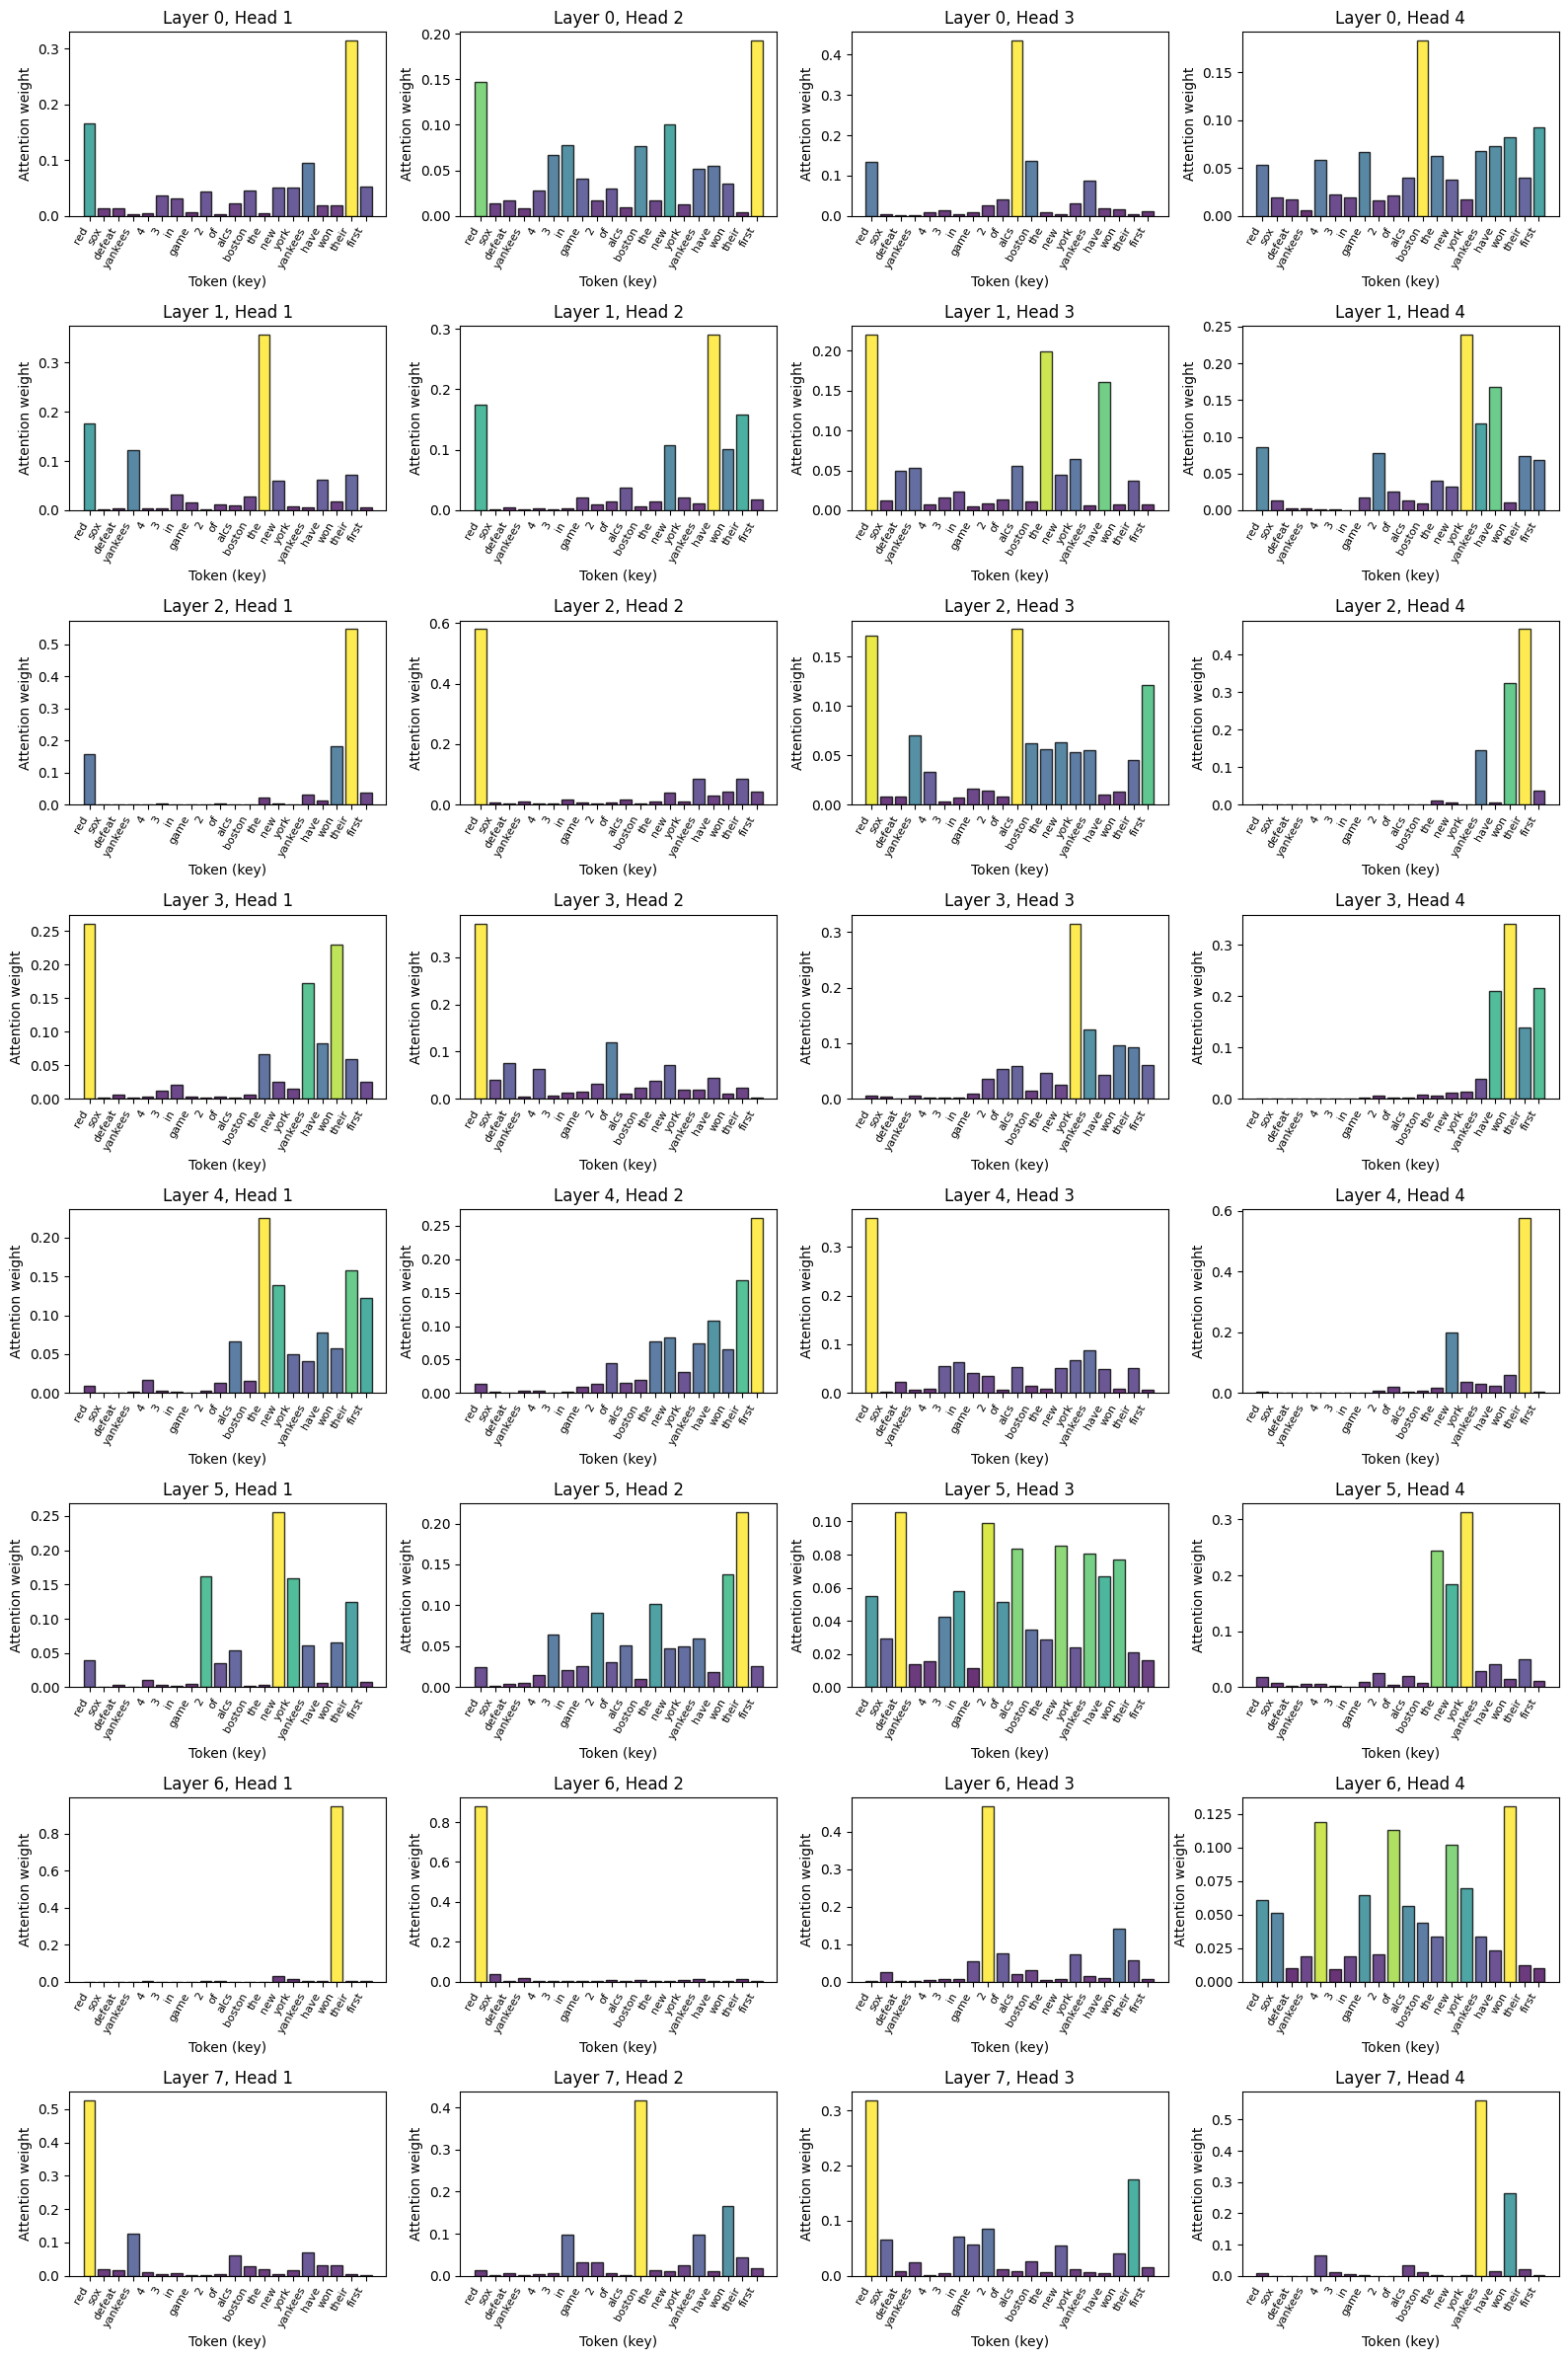

In [28]:
# Plot the attention weights for the second prompt
plot_attention_bar(storage_attn[1], storage_l2_cache[1].split(),num_heads=4, num_layers=8)

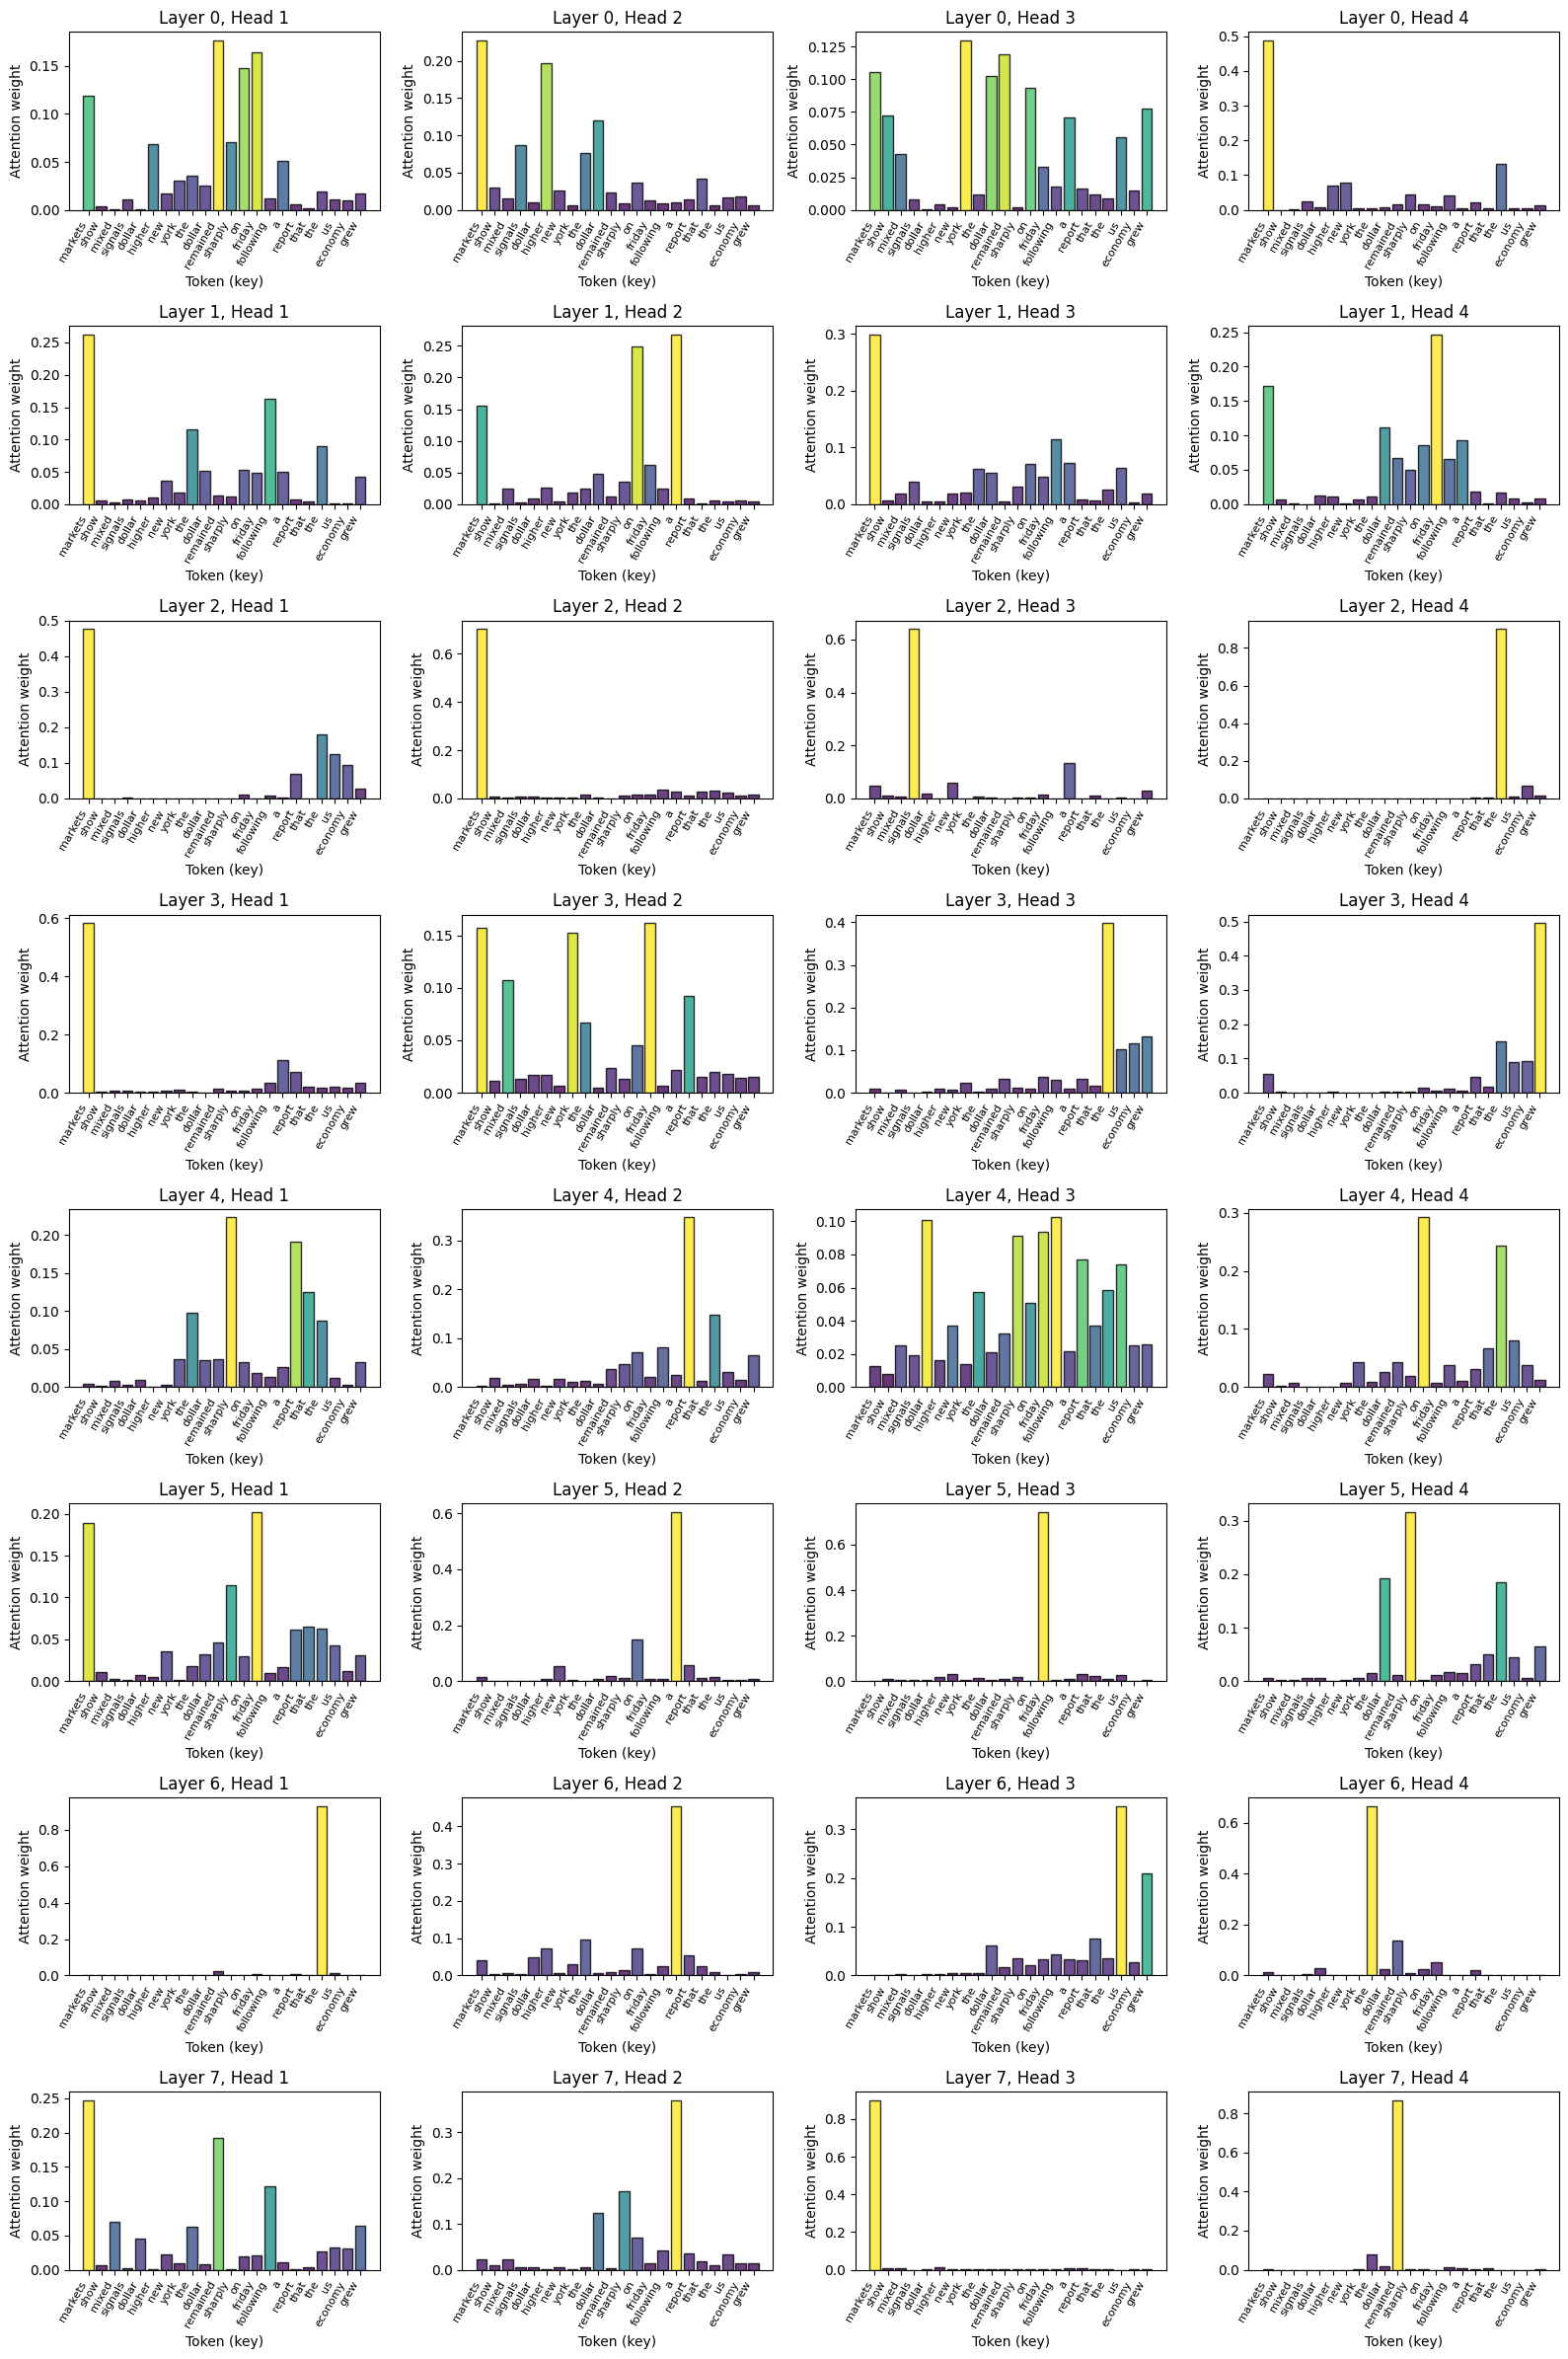

In [29]:
# Plot the attention weights for the third prompt
plot_attention_bar(storage_attn[2], storage_l2_cache[2].split(),num_heads=4, num_layers=8)

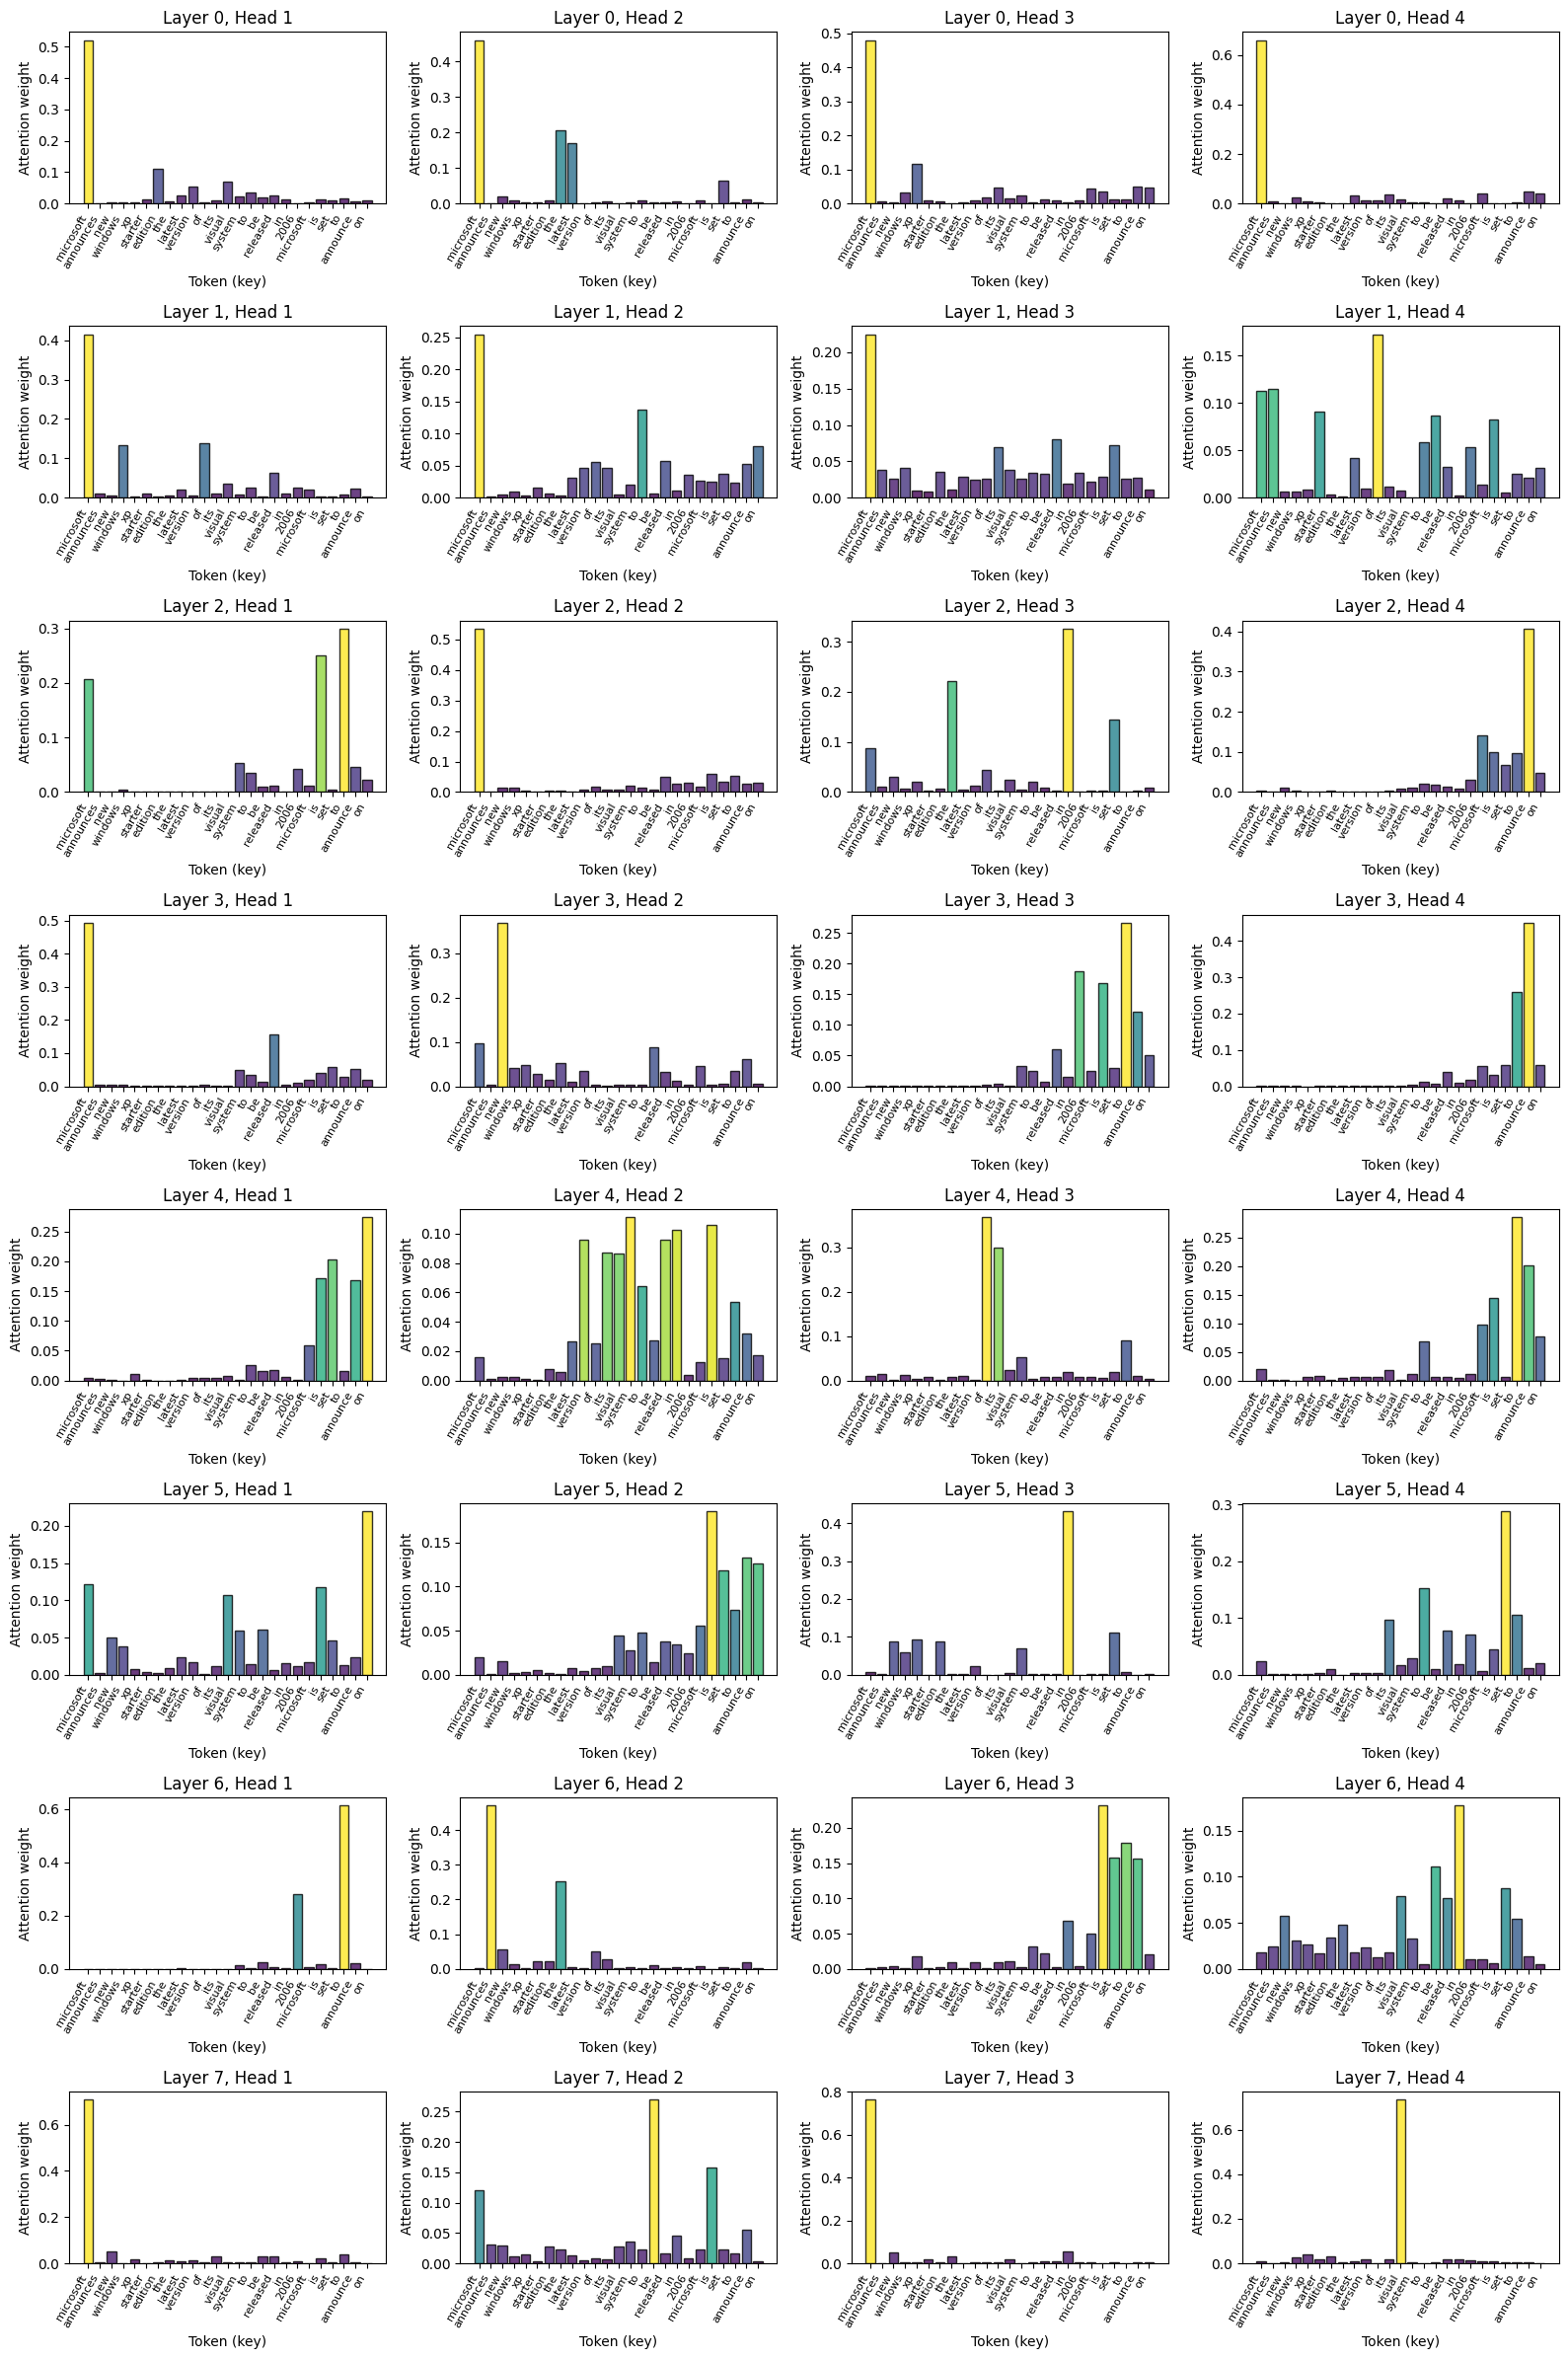

In [30]:
# Plot the attention weights for the fourth prompt
plot_attention_bar(storage_attn[3], storage_l2_cache[3].split(),num_heads=4, num_layers=8)

### Final checklist

1. Carefully check all textual descriptions and the code. Insert comments when needed. <ins>Check for TODO to see if you missed anything.</ins>
2. Run everything one final time. *Please do not send me notebooks with errors or cells that are not working.*
3. Send the completed notebook following the instructions on top.